In [24]:
# ===============================
# STEP 1: ENVIRONMENT SETUP
# ===============================

# Install required libraries
!pip install faker seaborn matplotlib --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random

# Configurations (Professional Touch)
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

fake = Faker()
np.random.seed(42)

print("✅ Environment setup complete")

✅ Environment setup complete


In [25]:
# ===============================
# STEP 2: DATA GENERATION
# ===============================

num_rows = 120000

data = {
    "order_id": np.arange(1, num_rows + 1),
    "user_id": np.random.randint(1000, 50000, num_rows),
    "product_id": np.random.randint(100, 1000, num_rows),
    "category": np.random.choice(["Electronics", "Clothing", "Home", "Sports"], num_rows),
    "price": np.round(np.random.uniform(10, 500, num_rows), 2),
    "quantity": np.random.randint(1, 5, num_rows),
    "discount": np.round(np.random.uniform(0, 0.3, num_rows), 2),
    "payment_method": np.random.choice(["Card", "UPI", "Cash"], num_rows),
    "order_date": pd.to_datetime(np.random.choice(pd.date_range("2023-01-01", "2025-01-01"), num_rows)),
    "city": [fake.city() for _ in range(num_rows)],
    "state": [fake.state() for _ in range(num_rows)],
    "country": ["USA"] * num_rows,
    "customer_age": np.random.randint(18, 70, num_rows),
    "is_returned": np.random.choice([0, 1], num_rows),
    "delivery_days": np.random.randint(1, 10, num_rows),
    "rating": np.round(np.random.uniform(1, 5, num_rows), 1),
    "shipping_cost": np.round(np.random.uniform(5, 50, num_rows), 2),
    "warehouse_id": np.random.randint(1, 20, num_rows),
}

df = pd.DataFrame(data)

print("✅ Data generated:", df.shape)
df.head()

✅ Data generated: (120000, 18)


,order_id,user_id,product_id,category,price,quantity,discount,payment_method,order_date,city,state,country,customer_age,is_returned,delivery_days,rating,shipping_cost,warehouse_id
0,1,16795,475,Electronics,28.74,1,0.15,UPI,2023-07-13,North Candace,Arizona,USA,63,0,8,4.8,15.52,17
1,2,1860,331,Sports,174.52,1,0.23,Card,2023-03-03,Michaelborough,New Hampshire,USA,39,1,1,2.5,36.90,17
2,3,39158,218,Electronics,433.82,2,0.11,Cash,2024-06-08,Jenkinsland,Arizona,USA,58,0,9,2.9,31.97,6
3,4,45732,343,Home,93.42,2,0.11,Card,2024-04-12,Harperstad,New York,USA,19,1,6,4.5,8.85,3
4,5,12284,794,Sports,330.70,1,0.02,Cash,2024-10-14,South Dustinland,Tennessee,USA,45,1,4,4.8,43.94,6


In [26]:
# Create folder structure (like real pipelines)
import os

os.makedirs("data/raw", exist_ok=True)

# Save raw data
df.to_csv("data/raw/ecommerce_raw.csv", index=False)

print("✅ Raw data saved at: data/raw/ecommerce_raw.csv")

✅ Raw data saved at: data/raw/ecommerce_raw.csv


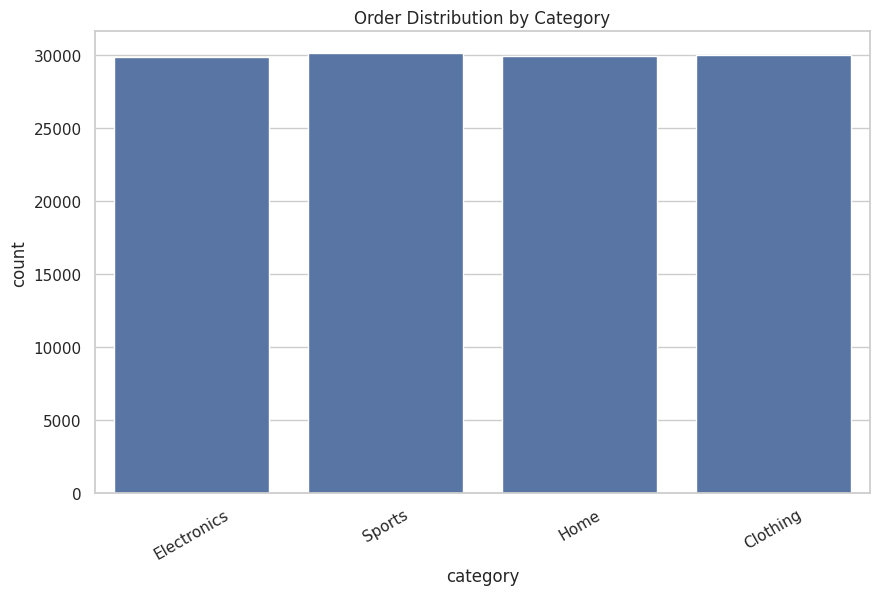

In [27]:
# ===============================
# BASIC DATA OVERVIEW
# ===============================

sns.countplot(data=df, x="category")
plt.title("Order Distribution by Category")
plt.xticks(rotation=30)
plt.show()

In [28]:
# ===============================
# LOAD RAW DATA
# ===============================

df = pd.read_csv("data/raw/ecommerce_raw.csv")

print("✅ Loaded raw data:", df.shape)
df.head()

✅ Loaded raw data: (120000, 18)


,order_id,user_id,product_id,category,price,quantity,discount,payment_method,order_date,city,state,country,customer_age,is_returned,delivery_days,rating,shipping_cost,warehouse_id
0,1,16795,475,Electronics,28.74,1,0.15,UPI,2023-07-13,North Candace,Arizona,USA,63,0,8,4.8,15.52,17
1,2,1860,331,Sports,174.52,1,0.23,Card,2023-03-03,Michaelborough,New Hampshire,USA,39,1,1,2.5,36.90,17
2,3,39158,218,Electronics,433.82,2,0.11,Cash,2024-06-08,Jenkinsland,Arizona,USA,58,0,9,2.9,31.97,6
3,4,45732,343,Home,93.42,2,0.11,Card,2024-04-12,Harperstad,New York,USA,19,1,6,4.5,8.85,3
4,5,12284,794,Sports,330.70,1,0.02,Cash,2024-10-14,South Dustinland,Tennessee,USA,45,1,4,4.8,43.94,6


In [29]:
# ===============================
# DATA CLEANING
# ===============================

# Remove duplicates
df = df.drop_duplicates()

# Simulate missing values
df.loc[df.sample(frac=0.01).index, "price"] = np.nan

# Fill missing values
df["price"].fillna(df["price"].median(), inplace=True)

# Convert date
df["order_date"] = pd.to_datetime(df["order_date"])

print("✅ Data cleaned")

✅ Data cleaned


/tmp/ipykernel_4356/1475240005.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(df["price"].median(), inplace=True)


In [30]:
# ===============================
# FEATURE ENGINEERING
# ===============================

df["total_amount"] = df["price"] * df["quantity"]
df["discounted_amount"] = df["total_amount"] * (1 - df["discount"])

df["order_month"] = df["order_date"].dt.month
df["order_year"] = df["order_date"].dt.year

print("✅ Features created")

✅ Features created


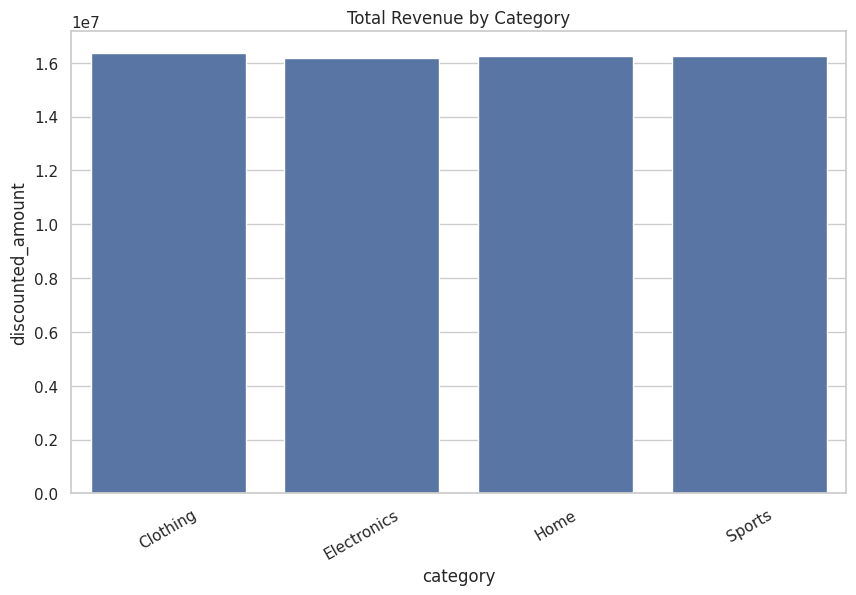

In [31]:
category_sales = df.groupby("category")["discounted_amount"].sum().reset_index()

sns.barplot(data=category_sales, x="category", y="discounted_amount")
plt.title("Total Revenue by Category")
plt.xticks(rotation=30)
plt.show()

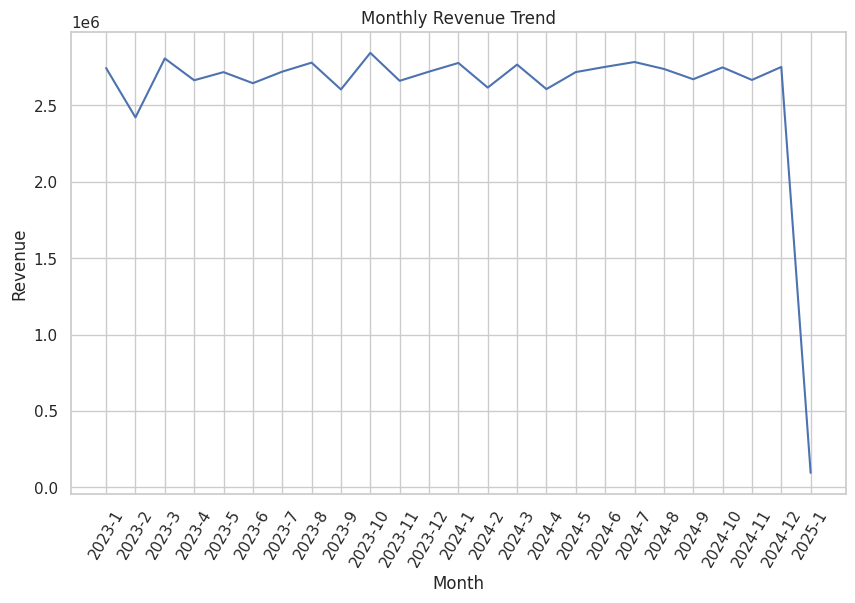

In [32]:
monthly_sales = df.groupby(["order_year", "order_month"])["discounted_amount"].sum().reset_index()

monthly_sales["year_month"] = monthly_sales["order_year"].astype(str) + "-" + monthly_sales["order_month"].astype(str)

plt.plot(monthly_sales["year_month"], monthly_sales["discounted_amount"])
plt.xticks(rotation=60)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

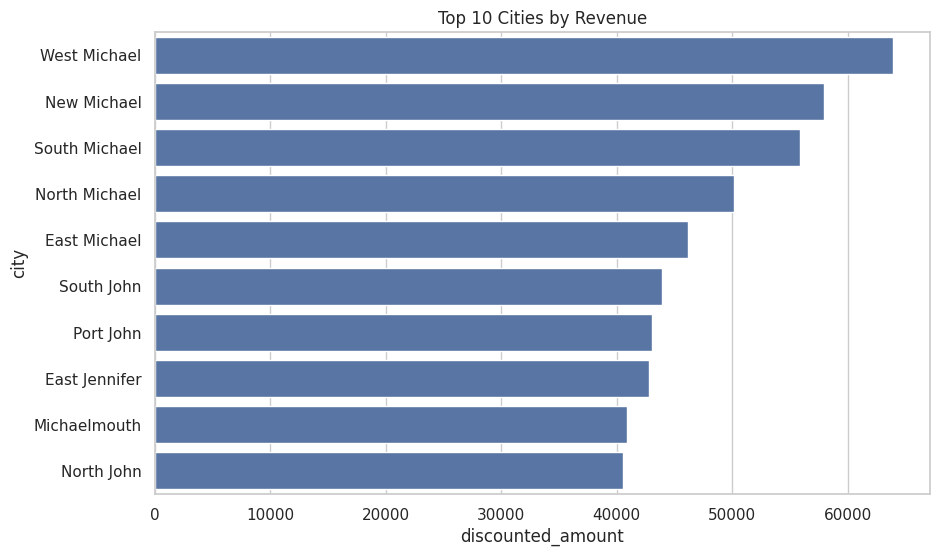

In [33]:
top_cities = df.groupby("city")["discounted_amount"].sum().nlargest(10).reset_index()

sns.barplot(data=top_cities, y="city", x="discounted_amount")
plt.title("Top 10 Cities by Revenue")
plt.show()

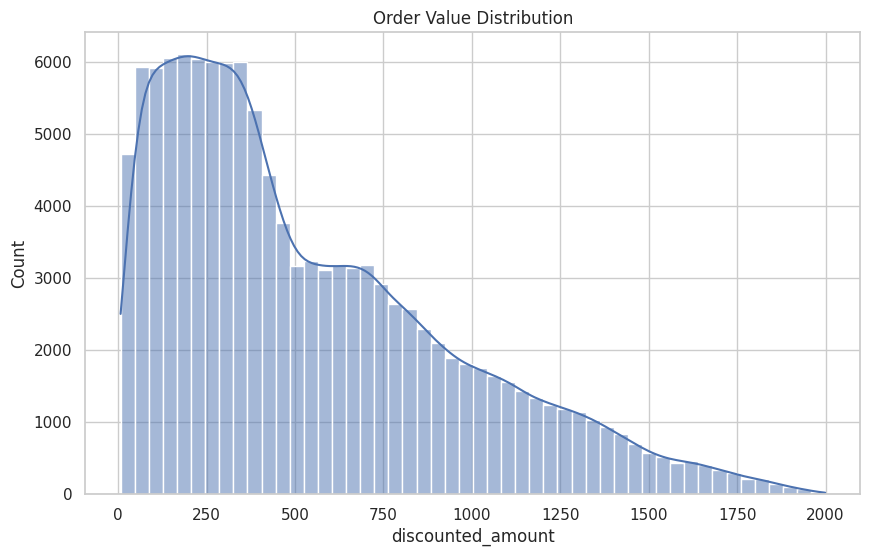

In [34]:
sns.histplot(df["discounted_amount"], bins=50, kde=True)
plt.title("Order Value Distribution")
plt.show()

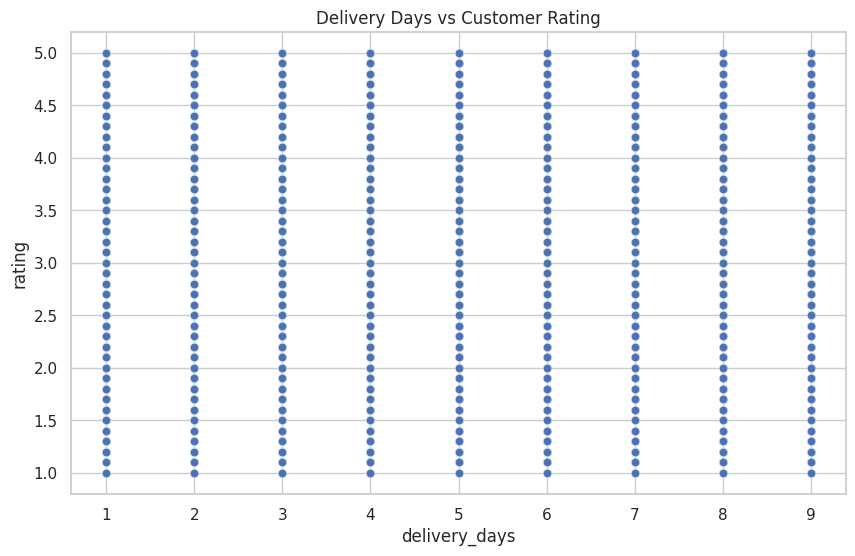

In [35]:
sns.scatterplot(data=df, x="delivery_days", y="rating", alpha=0.3)
plt.title("Delivery Days vs Customer Rating")
plt.show()

In [36]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/ecommerce_processed.csv", index=False)

print("✅ Processed data saved")

✅ Processed data saved


In [37]:
# ===============================
# LOAD PROCESSED DATA
# ===============================

df = pd.read_csv("data/processed/ecommerce_processed.csv")

print("✅ Processed data loaded:", df.shape)

✅ Processed data loaded: (120000, 22)


In [38]:
# ===============================
# CURATED LAYER TABLES
# ===============================

# Revenue by category
curated_category = df.groupby("category").agg({
    "discounted_amount": "sum",
    "order_id": "count"
}).reset_index()

curated_category.columns = ["category", "total_revenue", "total_orders"]

# Monthly KPI table
curated_monthly = df.groupby(["order_year", "order_month"]).agg({
    "discounted_amount": "sum",
    "order_id": "count",
    "user_id": "nunique"
}).reset_index()

curated_monthly.columns = ["year", "month", "revenue", "orders", "unique_customers"]

print("✅ Curated tables created")

✅ Curated tables created


In [39]:
total_revenue = df["discounted_amount"].sum()
total_orders = df["order_id"].count()
avg_order_value = df["discounted_amount"].mean()

print("====== KPI SUMMARY ======")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Avg Order Value: ${avg_order_value:.2f}")

====== KPI SUMMARY ======
Total Revenue: $65,004,604.71
Total Orders: 120000
Avg Order Value: $541.71


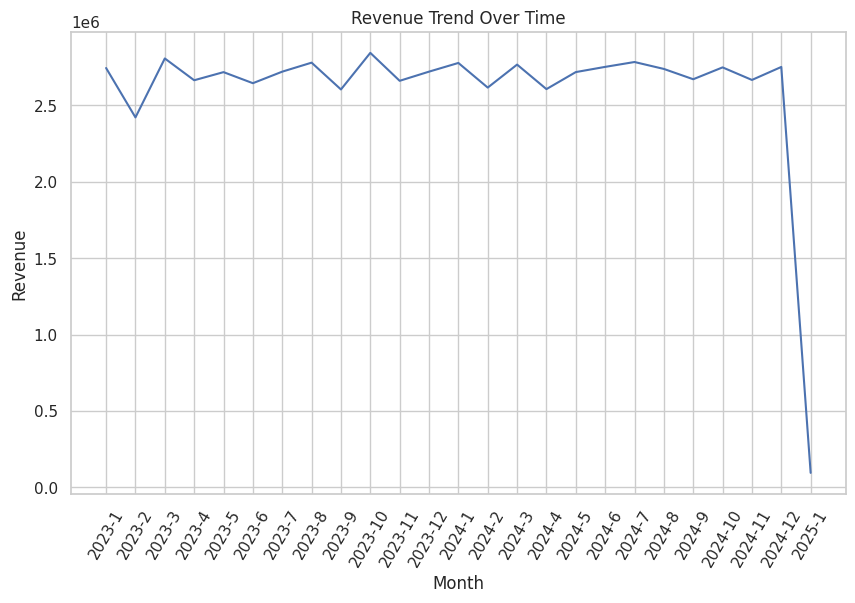

In [40]:
curated_monthly["year_month"] = curated_monthly["year"].astype(str) + "-" + curated_monthly["month"].astype(str)

plt.plot(curated_monthly["year_month"], curated_monthly["revenue"])
plt.xticks(rotation=60)
plt.title("Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

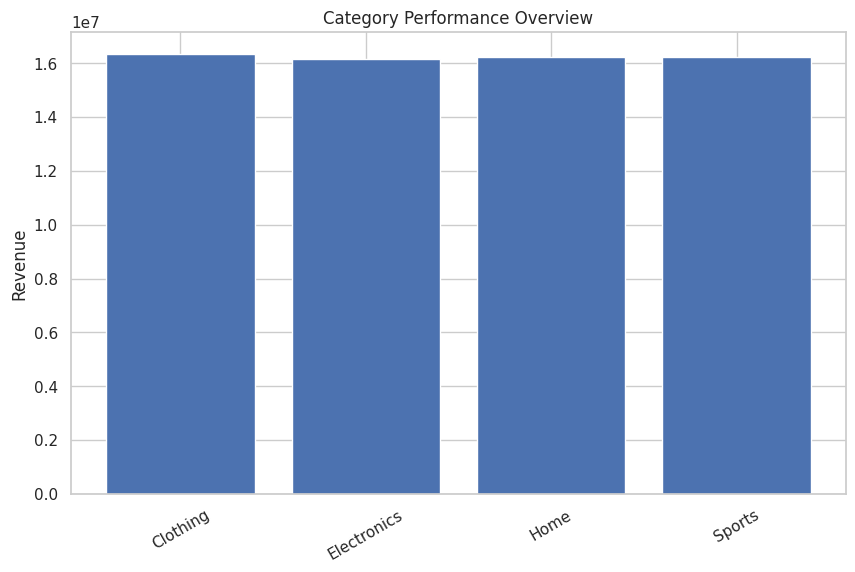

In [41]:
fig, ax1 = plt.subplots()

ax1.bar(curated_category["category"], curated_category["total_revenue"])
ax1.set_ylabel("Revenue")

plt.title("Category Performance Overview")
plt.xticks(rotation=30)

plt.show()

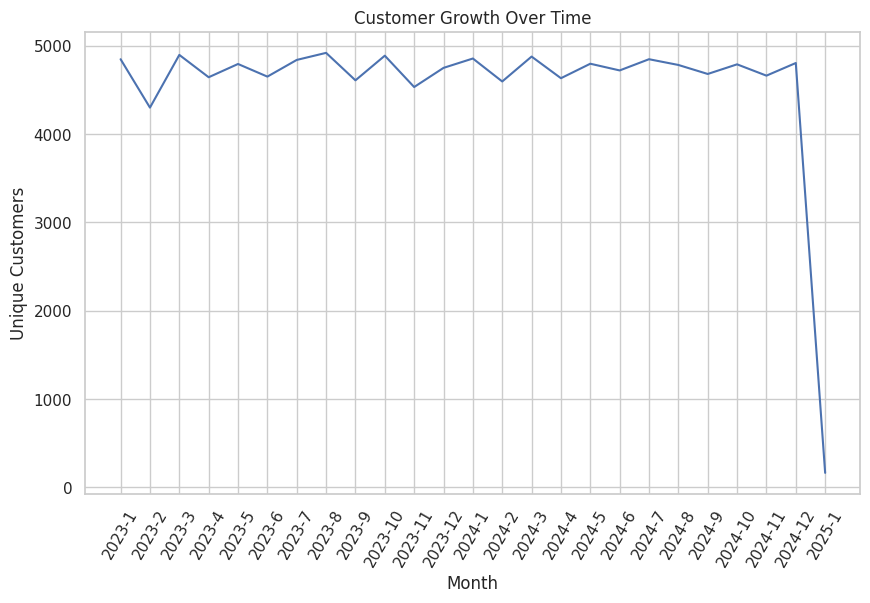

In [42]:
plt.plot(curated_monthly["year_month"], curated_monthly["unique_customers"])
plt.xticks(rotation=60)
plt.title("Customer Growth Over Time")
plt.xlabel("Month")
plt.ylabel("Unique Customers")
plt.show()

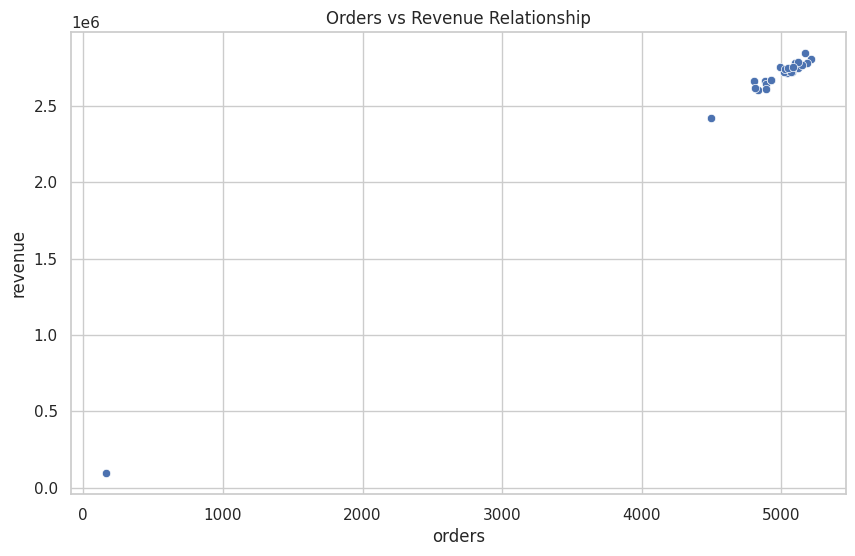

In [43]:
sns.scatterplot(data=curated_monthly, x="orders", y="revenue")
plt.title("Orders vs Revenue Relationship")
plt.show()

In [44]:
import os

os.makedirs("data/curated", exist_ok=True)

curated_category.to_csv("data/curated/category_kpis.csv", index=False)
curated_monthly.to_csv("data/curated/monthly_kpis.csv", index=False)

print("✅ Curated data saved")

✅ Curated data saved


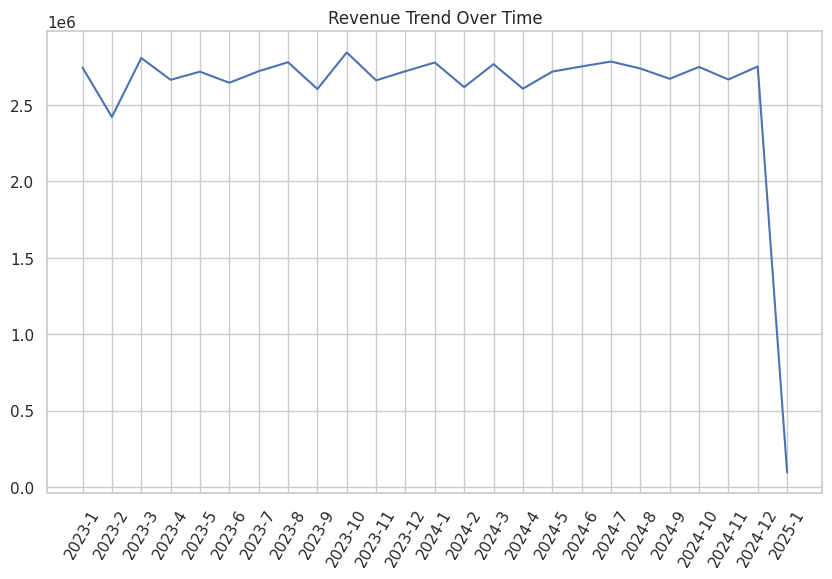

In [45]:
plt.plot(curated_monthly["year_month"], curated_monthly["revenue"])
plt.xticks(rotation=60)
plt.title("Revenue Trend Over Time")

import os
os.makedirs("outputs/charts", exist_ok=True)

plt.savefig("outputs/charts/revenue_trend.png", bbox_inches='tight')
plt.show()

In [46]:
# ===============================
# PIPELINE FUNCTION (SIMULATION)
# ===============================

def run_pipeline():
    print("🚀 Starting Data Pipeline...")

    # Load
    df = pd.read_csv("data/raw/ecommerce_raw.csv")

    # Clean
    df = df.drop_duplicates()
    df["price"].fillna(df["price"].median(), inplace=True)

    # Transform
    df["total_amount"] = df["price"] * df["quantity"]
    df["discounted_amount"] = df["total_amount"] * (1 - df["discount"])

    # Save processed
    df.to_csv("data/processed/ecommerce_processed.csv", index=False)

    print("✅ Pipeline executed successfully")

# Run pipeline
run_pipeline()

🚀 Starting Data Pipeline...


/tmp/ipykernel_4356/1181978333.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(df["price"].median(), inplace=True)


✅ Pipeline executed successfully


In [47]:
df.to_csv("data/raw/ecommerce_raw.csv", index=False)

In [48]:
from google.colab import files

files.download("data/raw/ecommerce_raw.csv")
files.download("data/processed/ecommerce_processed.csv")
files.download("data/curated/category_kpis.csv")
files.download("data/curated/monthly_kpis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>